In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv("1776250375-P2-Healthcare Analytics for Doctor Visits.csv")

In [10]:
df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [11]:
df.shape

(5190, 13)

In [12]:
df.columns

Index(['Unnamed: 0', 'visits', 'gender', 'age', 'income', 'illness', 'reduced',
       'health', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


In [14]:
df.describe()

,Unnamed: 0,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,2595.500000,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,1498.368279,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,1.000000,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,1298.250000,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,2595.500000,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,3892.750000,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,5190.000000,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [15]:
df = df.drop(columns=['Unnamed: 0'])

In [16]:
df.isnull().sum()

visits       0
gender       0
age          0
income       0
illness      0
reduced      0
health       0
private      0
freepoor     0
freerepat    0
nchronic     0
lchronic     0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(1320)

In [18]:
df['visits'].value_counts().sort_index()

visits
0    4141
1     782
2     174
3      30
4      24
5       9
6      12
7      12
8       5
9       1
Name: count, dtype: int64

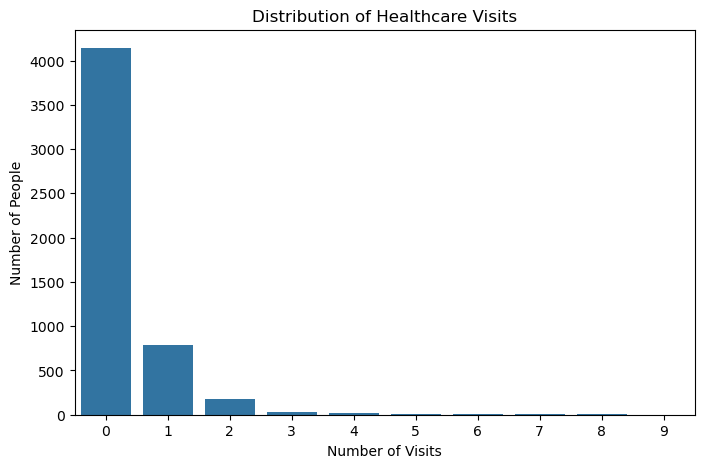

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='visits')

plt.title('Distribution of Healthcare Visits')
plt.xlabel('Number of Visits')
plt.ylabel('Number of People')

plt.show()

In [20]:
gender_visits = df.groupby('gender')['visits'].mean()

print(gender_visits)

gender
female    0.361954
male      0.236334
Name: visits, dtype: float64


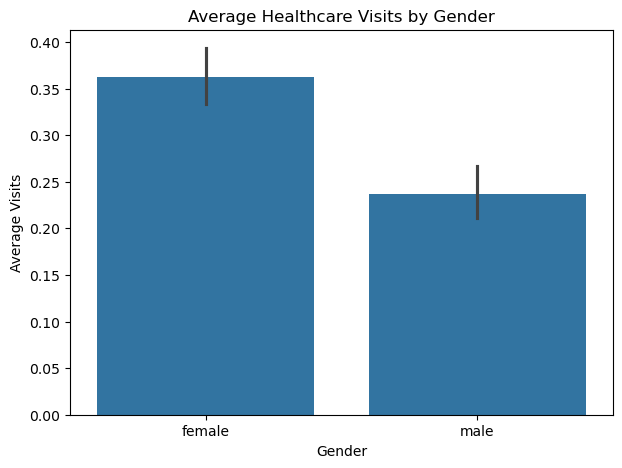

In [21]:
plt.figure(figsize=(7,5))

sns.barplot(data=df, x='gender', y='visits')

plt.title('Average Healthcare Visits by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Visits')

plt.show()

In [22]:
illness_visits = df.groupby('illness')['visits'].mean()

print(illness_visits)

illness
0    0.078507
1    0.295482
2    0.403805
3    0.420664
4    0.576642
5    0.813559
Name: visits, dtype: float64


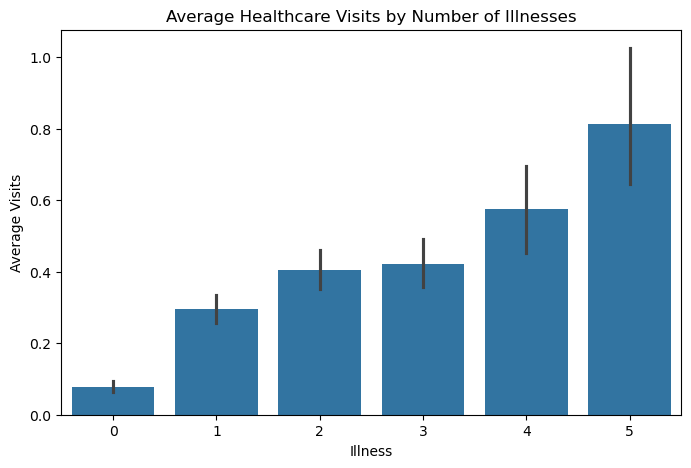

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x='illness', y='visits')

plt.title('Average Healthcare Visits by Number of Illnesses')
plt.xlabel('Illness')
plt.ylabel('Average Visits')

plt.show()

In [24]:
df.groupby('lchronic')['visits'].mean()

lchronic
no     0.261941
yes    0.603306
Name: visits, dtype: float64

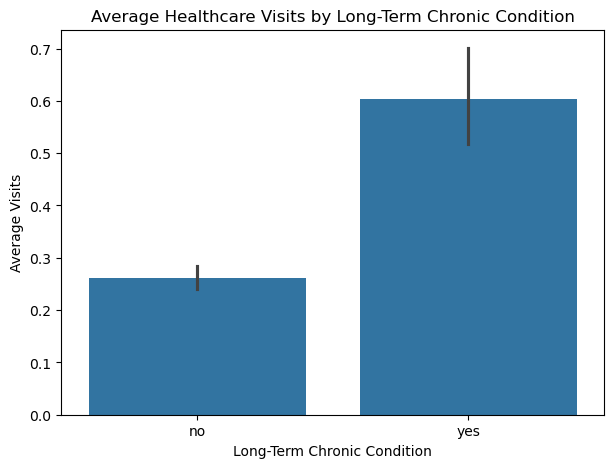

In [25]:
plt.figure(figsize=(7,5))

sns.barplot(data=df, x='lchronic', y='visits')

plt.title('Average Healthcare Visits by Long-Term Chronic Condition')
plt.xlabel('Long-Term Chronic Condition')
plt.ylabel('Average Visits')

plt.show()

In [26]:
health_visits = df.groupby('health')['visits'].mean()

print(health_visits)

health
0     0.199273
1     0.335358
2     0.381166
3     0.417582
4     0.534759
5     0.530303
6     0.625000
7     0.918033
8     0.476190
9     0.656250
10    1.523810
11    0.833333
12    1.000000
Name: visits, dtype: float64


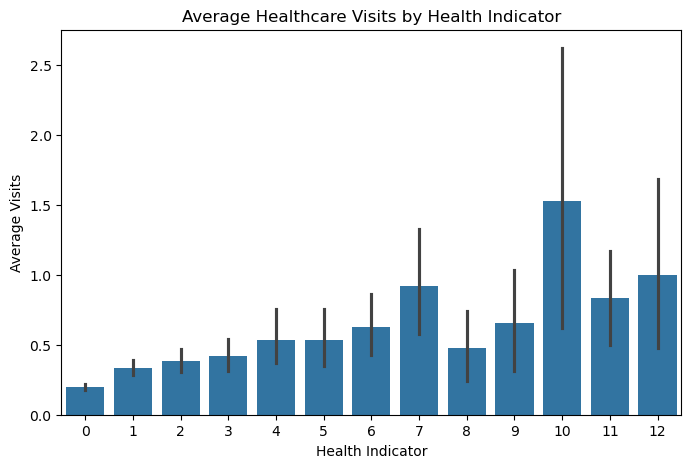

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x='health', y='visits')

plt.title('Average Healthcare Visits by Health Indicator')
plt.xlabel('Health Indicator')
plt.ylabel('Average Visits')

plt.show()

In [28]:
numeric_cols = ['visits', 'age', 'income', 'illness', 'reduced', 'health']

correlation = df[numeric_cols].corr()

print(correlation)

           visits       age    income   illness   reduced    health
visits   1.000000  0.124537 -0.076840  0.223552  0.418954  0.193272
age      0.124537  1.000000 -0.271073  0.204984  0.094745  0.018616
income  -0.076840 -0.271073  1.000000 -0.148812 -0.047545 -0.085790
illness  0.223552  0.204984 -0.148812  1.000000  0.218116  0.360110
reduced  0.418954  0.094745 -0.047545  0.218116  1.000000  0.280208
health   0.193272  0.018616 -0.085790  0.360110  0.280208  1.000000


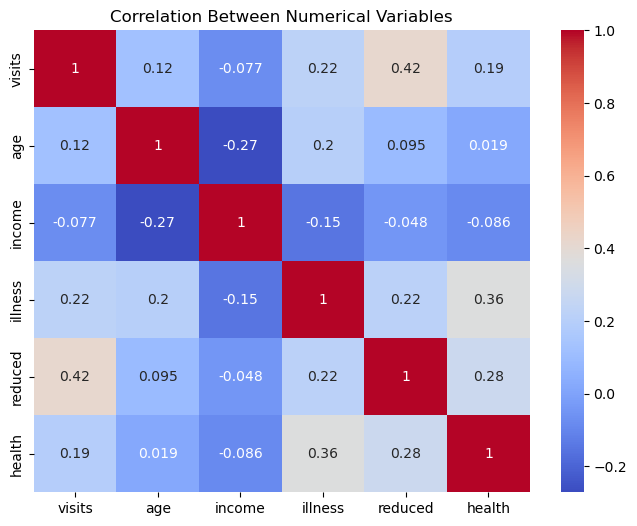

In [29]:
plt.figure(figsize=(8,6))

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title('Correlation Between Numerical Variables')

plt.show()